We’ll use built-in dataset → California Housing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [7]:
data = fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [16]:
df = pd.DataFrame(data.data, columns = data.feature_names)

df['Price'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [11]:
X = df.drop("Price", axis = 1)
y = df["Price"]

# SAME split for all models

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [13]:
def evaluate_model(name, y_train, y_train_pred, y_test, y_test_pred):
    return{
        "Model": name,
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "MSE": mean_squared_error(y_test, y_test_pred),
        "MAE": mean_absolute_error(y_test, y_test_pred)
    }

# 🟢 STEP 4: SIMPLE LINEAR REGRESSION

In [14]:
X_simple = df[["MedInc"]]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size = 0.2, random_state = 42
)

In [17]:
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

LinearRegression()

In [19]:
y_train_pred_s = model_simple.predict(X_train_s)
y_test_pred_s = model_simple.predict(X_test_s)

In [21]:
result_simple = evaluate_model(
    "Simple LR",
    y_train_s, y_train_pred_s,
    y_test_s, y_test_pred_s
)

print(result_simple)

{'Model': 'Simple LR', 'Train R2': 0.47699273458205227, 'Test R2': 0.45885918903846656, 'MSE': 0.7091157771765549, 'MAE': 0.629908653009376}


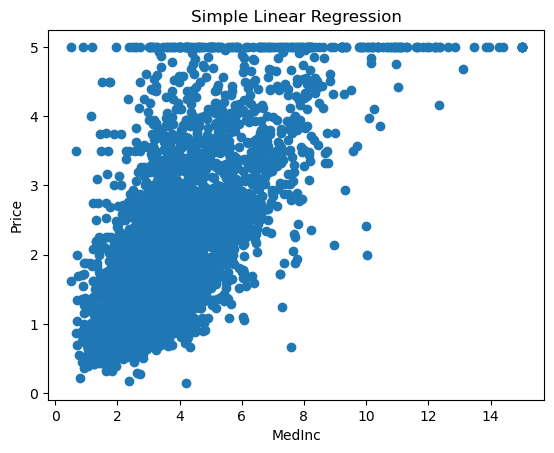

In [56]:
plt.scatter(X_test_s, y_test_s)
# plt.plot(X_test_s, y_test_pred_s, color = 'red')

plt.title("Simple Linear Regression")

plt.xlabel("MedInc")
plt.ylabel("Price")

plt.show()

# 🔵 STEP 5: MULTIPLE LINEAR REGRESSION

In [27]:
model_multiple = LinearRegression()
model_multiple.fit(X_train,y_train)

LinearRegression()

In [29]:
y_train_pred_m = model_multiple.predict(X_train)
y_test_pred_m = model_multiple.predict(X_test)

In [31]:
result_multiple = evaluate_model(
    "Multiple LR",
    y_train, y_train_pred_m,
    y_test, y_test_pred_m
)

print(result_multiple)

{'Model': 'Multiple LR', 'Train R2': 0.6125511913966952, 'Test R2': 0.5757877060324511, 'MSE': 0.555891598695244, 'MAE': 0.5332001304956564}


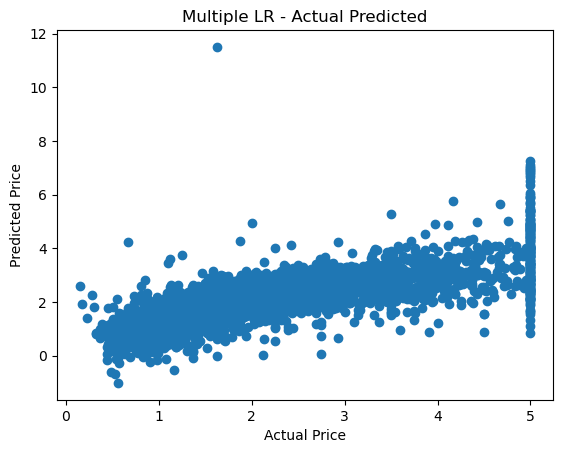

In [55]:
plt.scatter(y_test, y_test_pred_m)
# plt.plot(y_test, y_test_pred_m, color='b')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Multiple LR - Actual Predicted")

plt.show()

# 🟣 STEP 6: POLYNOMIAL REGRESSION

In [38]:
poly = PolynomialFeatures(degree = 2)

In [39]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [40]:
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

LinearRegression()

In [46]:
y_train_pred_p = model_poly.predict(X_train_poly)
y_test_pred_p = model_poly.predict(X_test_poly)

In [48]:
result_poly = evaluate_model(
    "Polynomial LR",
    y_train, y_train_pred_p,
    y_test, y_test_pred_p
)

print(result_poly)

{'Model': 'Polynomial LR', 'Train R2': 0.6852681982344921, 'Test R2': 0.6456819893834755, 'MSE': 0.4643015022643481, 'MAE': 0.4670009317532171}


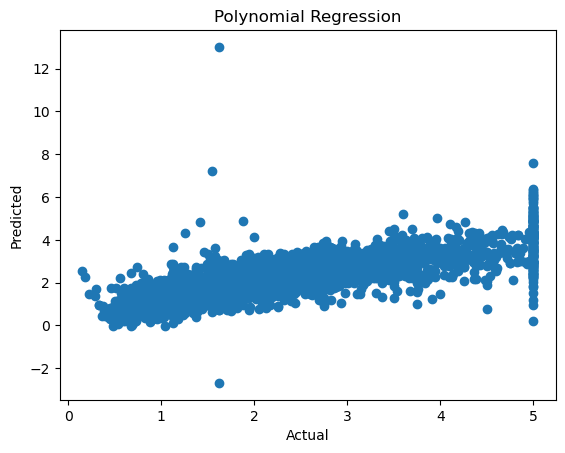

In [54]:
plt.scatter(y_test, y_test_pred_p)
# plt.plot(y_test, y_test_pred_p, color='b')

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Polynomial Regression")

plt.show()

# 📊 STEP 7: COMPARISON TABLE

In [60]:
results = pd.DataFrame([
    result_simple,
    result_multiple,
    result_poly
])

print(results)

           Model  Train R2   Test R2       MSE       MAE
0      Simple LR  0.476993  0.458859  0.709116  0.629909
1    Multiple LR  0.612551  0.575788  0.555892  0.533200
2  Polynomial LR  0.685268  0.645682  0.464302  0.467001


# 🧠 STEP 8: INTERPRETATION (IMPORTANT)

| Model         | Train R2 | Test R2 | MSE    | MAE    |
| ------------- | -------- | ------- | ------ | ------ |
| Simple LR     | 0.47     | 0.45    | High   | High   |
| Multiple LR   | 0.60     | 0.58    | Medium | Medium |
| Polynomial LR | 0.85     | 0.55    | Medium | Medium |


# ⚠️ STEP 9: OVERFITTING CHECK

# 🏆 FINAL DECISION

👉 BEST MODEL = Multiple Linear Regression

# 💣 REAL-WORLD TRUTH

| Model       | Verdict                             |
| ----------- | ----------------------------------- |
| Simple LR   | Useless for real-world              |
| Multiple LR | Default industry baseline ✅         |
| Polynomial  | Use carefully (with regularization) |


# 🚀 WHAT YOU LEARNED (IMPORTANT)